# Biomedical Data Science - Assignment 3
##### Shane Ferrell

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set()

In [23]:
df = pd.read_csv("kirby21AllLevels.csv")
df

,Unnamed: 0,rawid,roi,volume,min,max,mean,std,type,level,id,icv,tbv
0,1,kirby127a_3_1_ax.img,Telencephalon_L,531111,0.0,374.0,128.3013,51.8593,1,1,127,1378295,1268519
1,2,kirby127a_3_1_ax.img,Telencephalon_R,543404,0.0,300.0,135.0683,53.6471,1,1,127,1378295,1268519
2,3,kirby127a_3_1_ax.img,Diencephalon_L,9683,15.0,295.0,193.5488,32.2733,1,1,127,1378295,1268519
3,4,kirby127a_3_1_ax.img,Diencephalon_R,9678,10.0,335.0,193.7051,32.7869,1,1,127,1378295,1268519
4,5,kirby127a_3_1_ax.img,Mesencephalon,10268,55.0,307.0,230.8583,29.2249,1,1,127,1378295,1268519
...,...,...,...,...,...,...,...,...,...,...,...,...,...
16715,16716,kirby959a_3_1_ax.img,Caudate_tail_L,406,65.0,248.0,167.1302,34.9645,2,5,959,1313114,1207218
16716,16717,kirby959a_3_1_ax.img,Caudate_tail_R,311,70.0,270.0,175.3475,39.5329,2,5,959,1313114,1207218
16717,16718,kirby959a_3_1_ax.img,Chroid_LVetc_L,399,15.0,229.0,120.6084,35.9975,2,5,959,1313114,1207218
16718,16719,kirby959a_3_1_ax.img,Chroid_LVetc_R,323,14.0,211.0,111.9703,31.4684,2,5,959,1313114,1207218


In [4]:
kirby906a_ax_df = df.loc[df['rawid'] == 'kirby906a_ax.img'].copy()
kirby906a_ax_df

,Unnamed: 0,rawid,roi,volume,min,max,mean,std,type,level,id,icv,tbv
12540,12541,kirby906a_ax.img,Telencephalon_L,467063,2.0,350.0,165.2599,57.1707,1,1,906,1195015,1123076
12541,12542,kirby906a_ax.img,Telencephalon_R,470488,2.0,337.0,171.8695,59.3001,1,1,906,1195015,1123076
12542,12543,kirby906a_ax.img,Diencephalon_L,8801,60.0,327.0,227.1878,31.2303,1,1,906,1195015,1123076
12543,12544,kirby906a_ax.img,Diencephalon_R,9054,63.0,415.0,231.6770,31.1780,1,1,906,1195015,1123076
12544,12545,kirby906a_ax.img,Mesencephalon,9564,86.0,352.0,269.1003,28.6454,1,1,906,1195015,1123076
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13371,13372,kirby906a_ax.img,Caudate_tail_L,424,112.0,279.0,182.8215,31.9975,2,5,906,1195015,1123076
13372,13373,kirby906a_ax.img,Caudate_tail_R,386,83.0,286.0,186.3707,37.6639,2,5,906,1195015,1123076
13373,13374,kirby906a_ax.img,Chroid_LVetc_L,101,56.0,255.0,181.6190,39.8132,2,5,906,1195015,1123076
13374,13375,kirby906a_ax.img,Chroid_LVetc_R,84,53.0,271.0,181.9857,43.3901,2,5,906,1195015,1123076


In [5]:
telencephalon_L_volume = kirby906a_ax_df.loc[
    (kirby906a_ax_df['roi'] == 'Telencephalon_L') &
    (kirby906a_ax_df['type'] == 1) & (kirby906a_ax_df['level'] == 1)
]['volume'].sum()
print('type I level I telencephalon left volume: ', telencephalon_L_volume)

telencephalon_R_volume = kirby906a_ax_df.loc[
    (kirby906a_ax_df['roi'] == 'Telencephalon_R') &
    (kirby906a_ax_df['type'] == 1) & (kirby906a_ax_df['level'] == 1)
]['volume'].sum()
print('type I level I telencephalon right volume: ', telencephalon_R_volume)

type I level I telencephalon left volume:  467063
type I level I telencephalon right volume:  470488


In [6]:
telencephalon_volume_total = kirby906a_ax_df.loc[
    (kirby906a_ax_df['type'] == 1) & (kirby906a_ax_df['level'] == 1) &
    ((kirby906a_ax_df['roi'] == 'Telencephalon_L') | (kirby906a_ax_df['roi'] == 'Telencephalon_R'))
]['volume'].sum()

ICV_total = kirby906a_ax_df.loc[
    (kirby906a_ax_df['type'] == 1) & (kirby906a_ax_df['level'] == 1)
]['volume'].sum()

TBV_total = kirby906a_ax_df.loc[
    (kirby906a_ax_df['type'] == 1) & (kirby906a_ax_df['level'] == 1) &
    (kirby906a_ax_df['roi'] != 'CSF')
]['volume'].sum()

ICV_fraction = telencephalon_volume_total / ICV_total
TBV_fraction = telencephalon_volume_total / TBV_total

print("type I level I telencephalon ICV:", ICV_fraction)
print("type I level I telencephalon TBV:", TBV_fraction)

type I level I telencephalon ICV: 0.7845516583473847
type I level I telencephalon TBV: 0.8348063710737297


In [7]:
all_regions_df = kirby906a_ax_df.loc[kirby906a_ax_df['roi'] != 'CSF'][['roi', 'type', 'level', 'volume']].groupby('roi', as_index=False).sum()
all_regions_df

,roi,type,level,volume
0,ACR_L,3,10,24800
1,ACR_R,3,10,26248
2,AGWM_L,1,5,2919
3,AGWM_R,1,5,3266
4,AG_L,2,9,13170
...,...,...,...,...
420,subcallosal_ACC_R,3,10,1095
421,subgenualWM_ACC_L,1,5,218
422,subgenualWM_ACC_R,1,5,106
423,subgenual_ACC_L,3,10,3026


In [8]:
all_regions_t1l2_df = kirby906a_ax_df.loc[
    (kirby906a_ax_df['roi'] != 'CSF') & (kirby906a_ax_df['type'] == 1) & (kirby906a_ax_df['level'] == 2)
][['roi', 'type', 'level', 'volume']].groupby('roi', as_index=False).sum()
all_regions_t1l2_df.head()

,roi,type,level,volume
0,BasalForebrain_L,1,2,2686
1,BasalForebrain_R,1,2,2609
2,CerebralCortex_L,1,2,246947
3,CerebralCortex_R,1,2,245855
4,CerebralNucli_L,1,2,11685


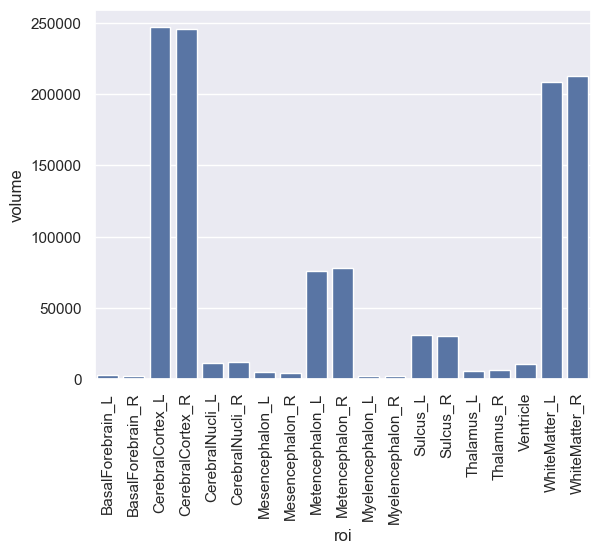

In [9]:
g = sns.barplot(x='roi', y='volume', data = all_regions_t1l2_df)
plt.xticks(rotation=90)
plt.show()

In [10]:
all_regions_t1l3_df = kirby906a_ax_df.loc[
    (kirby906a_ax_df['roi'] != 'CSF') & (kirby906a_ax_df['type'] == 1) & (kirby906a_ax_df['level'] == 3)
][['roi', 'type', 'level', 'volume']].groupby('roi', as_index=False).sum()
all_regions_t1l3_df.head(), all_regions_t1l3_df.tail()

(                roi  type  level  volume
 0      AnteriorWM_L     1      3   72167
 1      AnteriorWM_R     1      3   76270
 2  BasalForebrain_L     1      3    2686
 3  BasalForebrain_R     1      3    2609
 4       BasalGang_L     1      3   10250,
            roi  type  level  volume
 49  Temporal_R     1      3   55776
 50  Thalamus_L     1      3    6116
 51  Thalamus_R     1      3    6446
 52  midbrain_L     1      3    4842
 53  midbrain_R     1      3    4722)

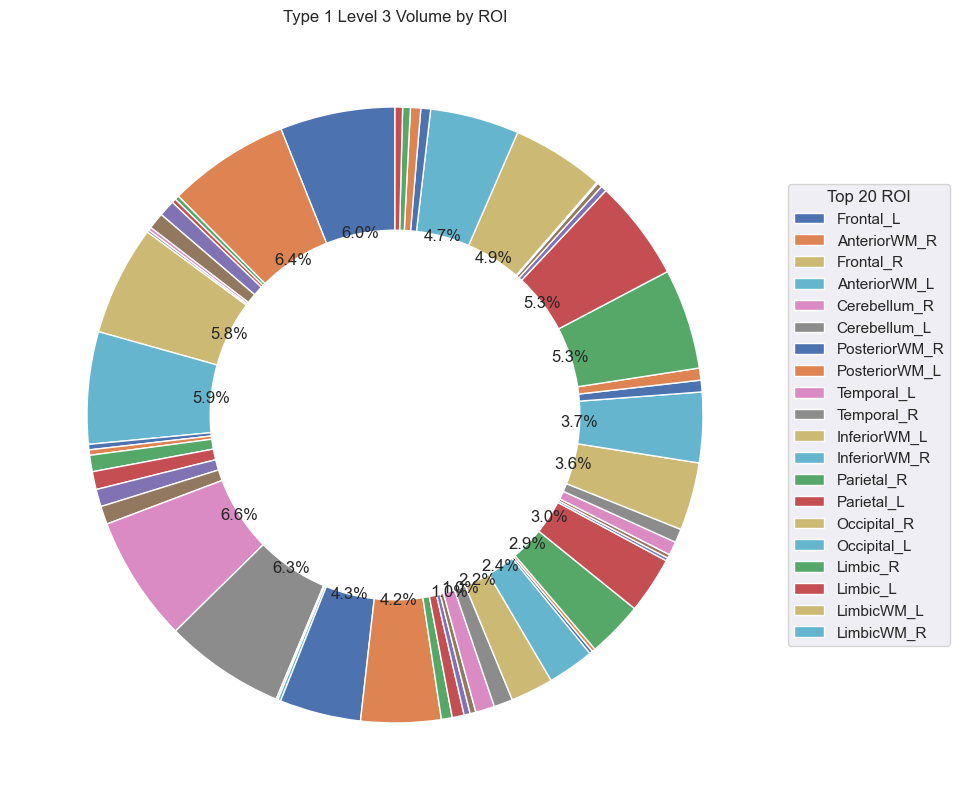

In [11]:
# 53 regions makes this chart hard to read,
# so I asked GPT how to display labels for only the 20 largest ROIs, and it produced this cell
top20_idx = all_regions_t1l3_df['volume'].nlargest(20).index

def autopct_top20(pct):
    autopct_top20.i += 1
    idx = all_regions_t1l3_df.index[autopct_top20.i]
    return f'{pct:.1f}%' if idx in top20_idx else ''

autopct_top20.i = -1
fig, ax = plt.subplots(figsize=(10, 10))

wedges, _, _ = ax.pie(
    all_regions_t1l3_df['volume'],
    autopct=autopct_top20,
    startangle=90,
    wedgeprops={'width': 0.4}
)

ax.legend(
    [wedges[i] for i in range(len(wedges)) if all_regions_t1l3_df.index[i] in top20_idx],
    all_regions_t1l3_df.loc[top20_idx, 'roi'],
    title='Top 20 ROI',
    loc='center left',
    bbox_to_anchor=(1, 0.5)
)

ax.set_title('Type 1 Level 3 Volume by ROI')
plt.show()

In [12]:
class_interests_df = pd.read_csv("classInterests.txt", sep='\t')
class_interests_df.head()

,Year,Program
0,Master's,BME
1,Master's,BME
2,Senior,BME
3,PhD,BME
4,PhD,Computer_Science


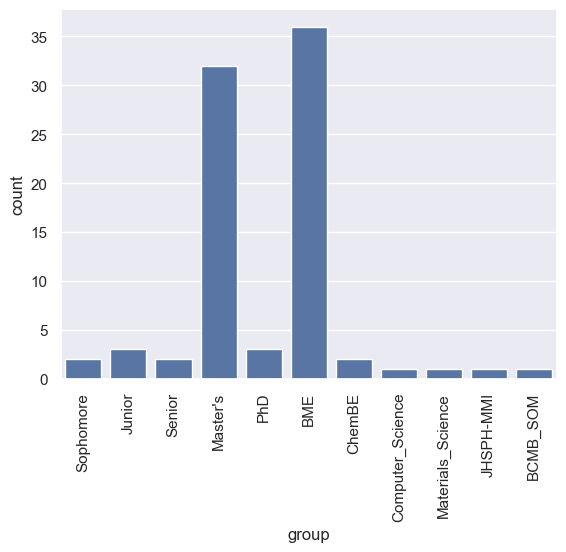

In [13]:
class_interests_counts_df = pd.concat([
    class_interests_df['Year'].value_counts(),
    class_interests_df['Program'].value_counts()
]).groupby(level=0).sum().reset_index()
class_interests_counts_df.columns = ['group', 'count']

g = sns.barplot(x='group', y='count', data=class_interests_counts_df, order=['Sophomore', 'Junior', 'Senior', "Master's", 'PhD',
    'BME', 'ChemBE', 'Computer_Science', 'Materials_Science', 'JHSPH-MMI', 'BCMB_SOM'])
plt.xticks(rotation=90)
plt.show()

In [14]:
gene_expression_df = pd.read_csv("GSE5859_exprs.csv")
gene_expression_df

,Unnamed: 0,GSM25581.CEL.gz,GSM25681.CEL.gz,GSM136524.CEL.gz,GSM136707.CEL.gz,GSM25553.CEL.gz,GSM136676.CEL.gz,GSM136711.CEL.gz,GSM136542.CEL.gz,GSM136535.CEL.gz,...,GSM48650.CEL.gz,GSM25687.CEL.gz,GSM25685.CEL.gz,GSM136549.CEL.gz,GSM25427.CEL.gz,GSM25525.CEL.gz,GSM25349.CEL.gz,GSM136727.CEL.gz,GSM25626.CEL.gz,GSM136725.CEL.gz
0,1007_s_at,6.333951,5.736190,6.156754,6.513010,6.061013,6.506493,6.863426,6.369645,6.646321,...,7.082636,6.315866,7.010165,6.460107,6.122355,6.330314,6.627014,6.133068,6.419444,6.488579
1,1053_at,7.255622,7.399993,7.491967,7.006123,7.250995,7.082581,6.842236,7.048487,7.042361,...,6.599718,7.412731,7.274429,6.928642,7.168782,7.235648,6.939184,7.280781,6.351776,7.517410
2,117_at,5.760106,4.825169,5.039387,5.414160,5.205697,5.300078,5.099337,5.156459,5.736109,...,6.231457,5.240717,5.275062,5.759827,5.409720,5.491938,5.113570,5.401876,5.537605,5.247190
3,121_at,6.935451,7.025210,7.543667,7.959781,7.223323,8.006816,8.102504,7.434617,7.532321,...,8.215096,7.677593,7.923624,7.219401,7.432338,6.785174,7.833862,7.607461,7.302935,7.331864
4,1255_g_at,3.597872,3.108801,3.128269,3.364947,3.125909,3.186834,3.311022,3.092042,3.167737,...,3.331424,3.043856,3.151900,3.132253,3.250600,2.984125,3.152269,3.225123,3.222731,3.175846
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8788,AFFX-r2-Ec-bioC-5_at,7.403732,8.173182,7.973033,6.993441,6.699585,6.926527,7.637367,7.006133,7.495841,...,6.542924,6.701961,5.589173,6.999664,7.852193,7.728074,8.243135,6.597565,8.454131,6.635873
8789,AFFX-r2-Ec-bioD-3_at,9.499829,10.147961,11.527503,10.814206,10.629492,10.702125,11.285036,11.055667,11.388749,...,11.160386,11.321130,10.944250,11.098619,10.065078,10.222762,10.265151,11.160541,10.333127,10.762506
8790,AFFX-r2-Ec-bioD-5_at,9.087917,9.356494,11.116875,10.056376,10.344678,10.186448,10.663689,10.411306,10.761674,...,10.669841,10.725765,9.989154,10.428633,9.288700,9.378446,9.569521,10.421423,9.766366,10.108590
8791,AFFX-r2-P1-cre-3_at,10.499176,11.039103,2.721370,2.734304,5.357892,2.798261,2.802282,2.674753,2.881834,...,2.774188,5.756867,4.570855,2.633058,10.544423,10.714675,10.901787,2.535893,10.903407,2.813128


In [15]:
gene_expression_df = gene_expression_df.drop(columns='Unnamed: 0')
gene_expression_df_pt1 = gene_expression_df.sub(gene_expression_df.mean(axis=1), axis=0)
gene_expression_df_pt1

,GSM25581.CEL.gz,GSM25681.CEL.gz,GSM136524.CEL.gz,GSM136707.CEL.gz,GSM25553.CEL.gz,GSM136676.CEL.gz,GSM136711.CEL.gz,GSM136542.CEL.gz,GSM136535.CEL.gz,GSM25399.CEL.gz,...,GSM48650.CEL.gz,GSM25687.CEL.gz,GSM25685.CEL.gz,GSM136549.CEL.gz,GSM25427.CEL.gz,GSM25525.CEL.gz,GSM25349.CEL.gz,GSM136727.CEL.gz,GSM25626.CEL.gz,GSM136725.CEL.gz
0,-0.049313,-0.647073,-0.226509,0.129747,-0.322250,0.123230,0.480163,-0.013618,0.263058,-0.572333,...,0.699373,-0.067397,0.626902,0.076844,-0.260908,-0.052949,0.243751,-0.250195,0.036180,0.105316
1,0.163992,0.308363,0.400337,-0.085507,0.159365,-0.009050,-0.249394,-0.043143,-0.049269,-0.425005,...,-0.491913,0.321100,0.182799,-0.162988,0.077152,0.144017,-0.152446,0.189150,-0.739855,0.425779
2,0.283074,-0.651863,-0.437645,-0.062873,-0.271335,-0.176954,-0.377696,-0.320573,0.259077,0.330464,...,0.754425,-0.236315,-0.201970,0.282794,-0.067313,0.014905,-0.363462,-0.075156,0.060573,-0.229842
3,-0.648591,-0.558832,-0.040375,0.375740,-0.360718,0.422774,0.518462,-0.149425,-0.051720,0.127419,...,0.631054,0.093552,0.339583,-0.364641,-0.151704,-0.798867,0.249820,0.023419,-0.281107,-0.252178
4,0.400185,-0.088886,-0.069418,0.167261,-0.071777,-0.010852,0.113335,-0.105644,-0.029949,-0.228108,...,0.133737,-0.153830,-0.045787,-0.065434,0.052913,-0.213562,-0.045417,0.027436,0.025044,-0.021841
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8788,0.272703,1.042153,0.842004,-0.137588,-0.431444,-0.204502,0.506338,-0.124896,0.364811,3.426462,...,-0.588105,-0.429068,-1.541857,-0.131365,0.721164,0.597045,1.112106,-0.533464,1.323102,-0.495156
8789,-1.086185,-0.438053,0.941489,0.228192,0.043478,0.116111,0.699022,0.469653,0.802735,1.449105,...,0.574372,0.735116,0.358236,0.512605,-0.520936,-0.363252,-0.320863,0.574527,-0.252887,0.176492
8790,-0.894001,-0.625424,1.134957,0.074458,0.362761,0.204530,0.681772,0.429388,0.779757,1.402459,...,0.687923,0.743847,0.007236,0.446716,-0.693218,-0.603472,-0.412396,0.439506,-0.215551,0.126673
8791,4.832515,5.372443,-2.945291,-2.932357,-0.308769,-2.868399,-2.864378,-2.991908,-2.784827,6.584329,...,-2.892473,0.090207,-1.095805,-3.033603,4.877762,5.048014,5.235127,-3.130768,5.236746,-2.853533


In [16]:
gene_expression_df_pt2 = gene_expression_df_pt1.sub(gene_expression_df_pt1.mean(axis=0), axis=1)
gene_expression_df_pt2

,GSM25581.CEL.gz,GSM25681.CEL.gz,GSM136524.CEL.gz,GSM136707.CEL.gz,GSM25553.CEL.gz,GSM136676.CEL.gz,GSM136711.CEL.gz,GSM136542.CEL.gz,GSM136535.CEL.gz,GSM25399.CEL.gz,...,GSM48650.CEL.gz,GSM25687.CEL.gz,GSM25685.CEL.gz,GSM136549.CEL.gz,GSM25427.CEL.gz,GSM25525.CEL.gz,GSM25349.CEL.gz,GSM136727.CEL.gz,GSM25626.CEL.gz,GSM136725.CEL.gz
0,-0.024490,-0.640032,-0.223988,0.114936,-0.428929,0.109485,0.457383,-0.017008,0.250137,-0.462337,...,0.678049,-0.061456,0.665913,0.076758,-0.251423,-0.031388,0.235241,-0.261128,0.041275,0.090015
1,0.188815,0.315404,0.402858,-0.100318,0.052687,-0.022794,-0.272174,-0.046533,-0.062190,-0.315009,...,-0.513237,0.327042,0.221810,-0.163074,0.086637,0.165579,-0.160956,0.178217,-0.734760,0.410478
2,0.307897,-0.644822,-0.435124,-0.077684,-0.378014,-0.190699,-0.400475,-0.323963,0.246157,0.440460,...,0.733100,-0.230374,-0.162959,0.282708,-0.057828,0.036467,-0.371972,-0.086090,0.065668,-0.245143
3,-0.623768,-0.551790,-0.037853,0.360928,-0.467397,0.409030,0.495682,-0.152814,-0.064641,0.237415,...,0.609730,0.099493,0.378593,-0.364727,-0.142219,-0.777306,0.241310,0.012486,-0.276012,-0.267479
4,0.425008,-0.081844,-0.066896,0.152450,-0.178456,-0.024597,0.090556,-0.109034,-0.042870,-0.118111,...,0.112413,-0.147889,-0.006776,-0.065520,0.062398,-0.192001,-0.053927,0.016503,0.030139,-0.037142
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8788,0.297526,1.049194,0.844525,-0.152399,-0.538123,-0.218246,0.483558,-0.128286,0.351891,3.536458,...,-0.609429,-0.423127,-1.502846,-0.131451,0.730648,0.618607,1.103596,-0.544398,1.328197,-0.510458
8789,-1.061362,-0.431011,0.944010,0.213381,-0.063201,0.102366,0.676242,0.466263,0.789815,1.559101,...,0.553047,0.741058,0.397247,0.512519,-0.511451,-0.341690,-0.329373,0.563594,-0.247792,0.161191
8790,-0.869178,-0.618382,1.137478,0.059647,0.256082,0.190786,0.658992,0.425998,0.766836,1.512455,...,0.666599,0.749789,0.046247,0.446630,-0.683733,-0.581910,-0.420906,0.428572,-0.210456,0.111371
8791,4.857338,5.379484,-2.942770,-2.947168,-0.415447,-2.882144,-2.887158,-2.995298,-2.797747,6.694326,...,-2.913797,0.096148,-1.056795,-3.033689,4.887247,5.069575,5.226617,-3.141702,5.241841,-2.868834


In [17]:
gene_expression_df_pt3 = gene_expression_df_pt2.div(gene_expression_df_pt2.std(axis=0), axis=1)
gene_expression_df_pt3

,GSM25581.CEL.gz,GSM25681.CEL.gz,GSM136524.CEL.gz,GSM136707.CEL.gz,GSM25553.CEL.gz,GSM136676.CEL.gz,GSM136711.CEL.gz,GSM136542.CEL.gz,GSM136535.CEL.gz,GSM25399.CEL.gz,...,GSM48650.CEL.gz,GSM25687.CEL.gz,GSM25685.CEL.gz,GSM136549.CEL.gz,GSM25427.CEL.gz,GSM25525.CEL.gz,GSM25349.CEL.gz,GSM136727.CEL.gz,GSM25626.CEL.gz,GSM136725.CEL.gz
0,-0.062810,-1.694428,-0.797346,0.362538,-1.152413,0.366177,1.252187,-0.054154,1.008166,-0.730639,...,1.446603,-0.185273,1.615970,0.245537,-0.568262,-0.069236,0.617954,-0.598607,0.088393,0.257410
1,0.484259,0.835005,1.434085,-0.316432,0.141554,-0.076237,-0.745136,-0.148166,-0.250652,-0.497815,...,-1.094982,0.985940,0.538265,-0.521649,0.195814,0.365237,-0.422815,0.408542,-1.573530,1.173822
2,0.789673,-1.707110,-1.548943,-0.245036,-1.015618,-0.637799,-1.096388,-1.031533,0.992122,0.696068,...,1.564055,-0.694512,-0.395453,0.904341,-0.130702,0.080440,-0.977132,-0.197351,0.140632,-0.701024
3,-1.599798,-1.460817,-0.134750,1.138467,-1.255766,1.368016,1.357039,-0.486577,-0.260531,0.375192,...,1.300847,0.299944,0.918732,-1.166704,-0.321440,-1.714599,0.633897,0.028623,-0.591095,-0.764897
4,1.090032,-0.216675,-0.238137,0.480868,-0.479461,-0.082265,0.247916,-0.347177,-0.172784,-0.186654,...,0.239831,-0.445844,-0.016443,-0.209588,0.141031,-0.423519,-0.141661,0.037831,0.064544,-0.106213
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8788,0.763075,2.777651,3.006323,-0.480709,-1.445787,-0.729933,1.323845,-0.408476,1.418280,5.588729,...,-1.300205,-1.275609,-3.646955,-0.420492,1.651396,1.364537,2.899034,-1.247970,2.844410,-1.459729
8789,-2.722110,-1.141065,3.360467,0.673063,-0.169803,0.342368,1.851361,1.484632,3.183311,2.463877,...,1.179916,2.234082,0.963998,1.639471,-1.155970,-0.753708,-0.865229,1.291974,-0.530662,0.460950
8790,-2.229208,-1.637114,4.049170,0.188144,0.688022,0.638090,1.804134,1.356425,3.090696,2.390161,...,1.422176,2.260404,0.112226,1.428700,-1.545359,-1.283592,-1.105678,0.982453,-0.450704,0.318483
8791,12.457774,14.241719,-10.475605,-9.296175,-1.116192,-9.639443,-7.904224,-9.537356,-11.276184,10.579166,...,-6.216530,0.289860,-2.564523,-9.704306,11.046052,11.182587,13.729787,-7.201991,11.225705,-8.203855


In [18]:
healthcare_df = pd.read_csv("healthcare-spending.csv", skiprows=2, skipfooter=16)
healthcare_df = healthcare_df[healthcare_df['Location'] != 'United States'].reset_index(drop=True)
healthcare_df.head()

C:\Users\Shane\AppData\Local\Temp\ipykernel_12512\3689158555.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  healthcare_df = pd.read_csv("healthcare-spending.csv", skiprows=2, skipfooter=16)


,Location,1991__Total Health Spending,1992__Total Health Spending,1993__Total Health Spending,1994__Total Health Spending,1995__Total Health Spending,1996__Total Health Spending,1997__Total Health Spending,1998__Total Health Spending,1999__Total Health Spending,...,2005__Total Health Spending,2006__Total Health Spending,2007__Total Health Spending,2008__Total Health Spending,2009__Total Health Spending,2010__Total Health Spending,2011__Total Health Spending,2012__Total Health Spending,2013__Total Health Spending,2014__Total Health Spending
0,Alabama,10393,11284,12028,12742,13590,14450,15462,15860,16451,...,25338,26638,27700,28765,30095,30728,31398,32848,33788,35263
1,Alaska,1458,1558,1661,1728,1879,2076,2240,2386,2569,...,4765,5048,5426,5807,6112,6519,6928,7406,7684,8151
2,Arizona,9269,9815,10655,11364,12042,12850,13418,14465,15550,...,28190,30766,33366,35547,37258,38620,39295,40495,41481,43356
3,Arkansas,5632,6022,6397,6810,7343,7817,8393,8814,9407,...,14611,15431,16426,17246,18071,18735,19356,20076,20500,21980
4,California,81438,87949,91963,94245,96870,100215,103681,111224,116036,...,182958,194413,209397,221013,229541,241916,253844,266767,278168,291989


In [19]:
healthcare_df = healthcare_df.melt(id_vars='Location', var_name='Year', value_name='Spending')
healthcare_df['Year'] = healthcare_df['Year'].str.extract(r'(\d{4})').astype(int)
healthcare_df

,Location,Year,Spending
0,Alabama,1991,10393
1,Alaska,1991,1458
2,Arizona,1991,9269
3,Arkansas,1991,5632
4,California,1991,81438
...,...,...,...
1219,Virginia,2014,62847
1220,Washington,2014,55819
1221,West Virginia,2014,17491
1222,Wisconsin,2014,50109


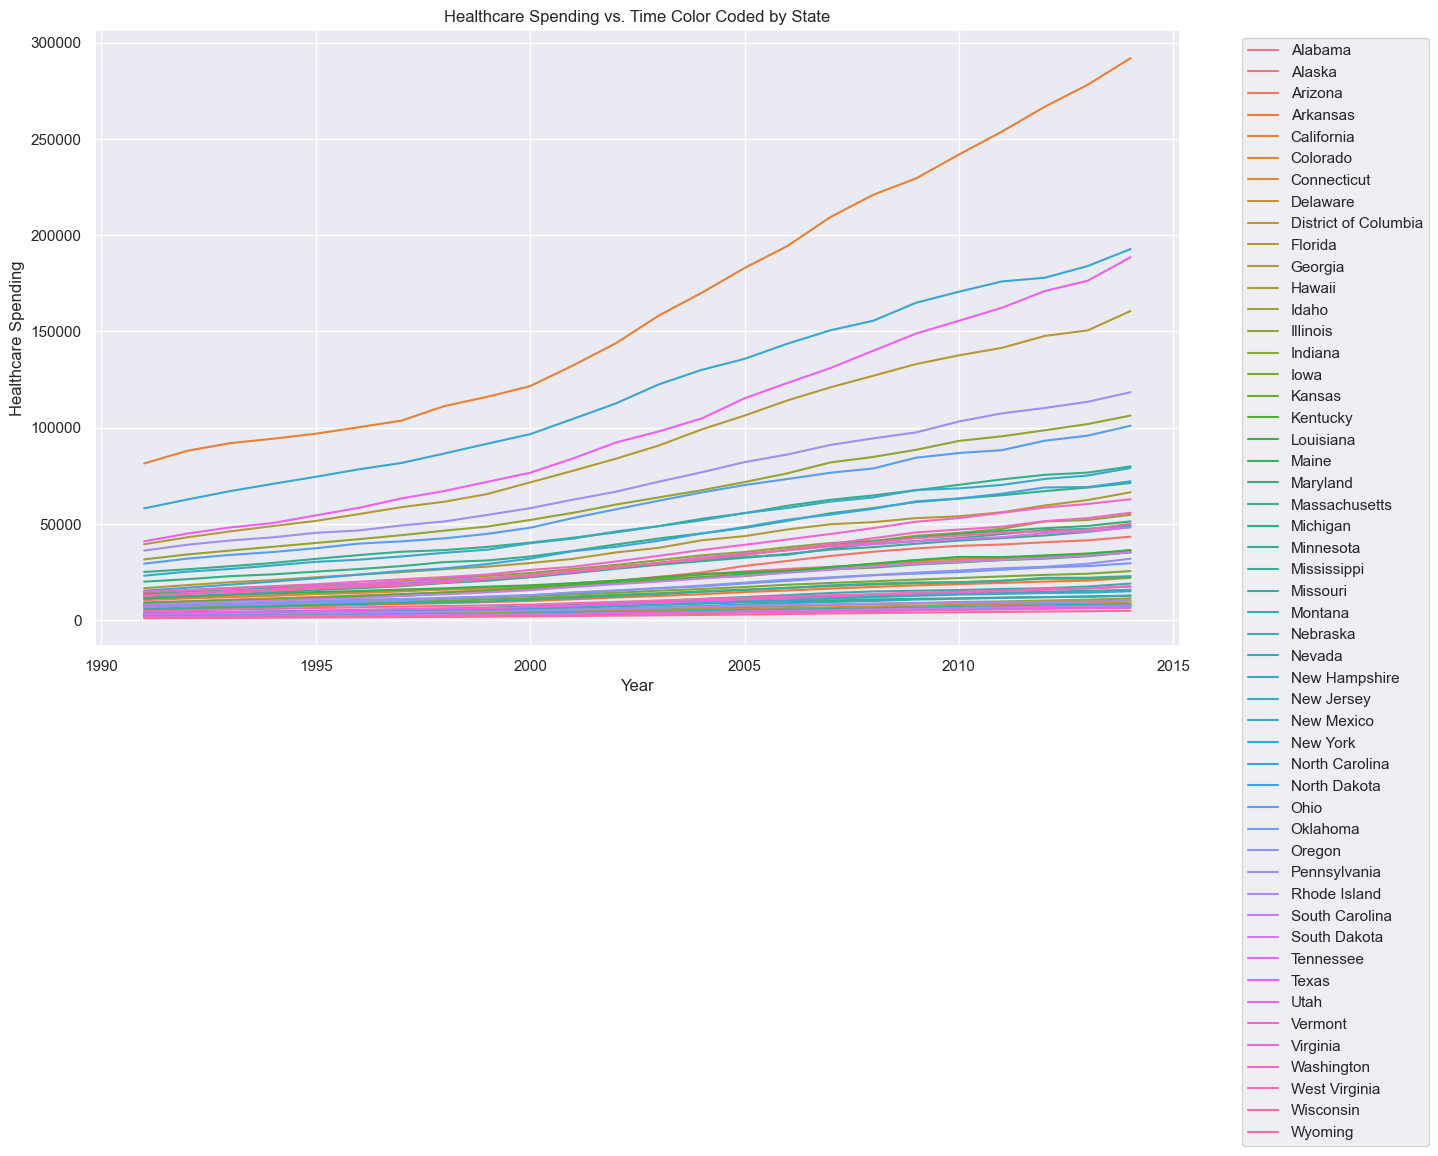

In [20]:
plt.figure(figsize=(14, 8))
sns.lineplot(data=healthcare_df, x='Year', y='Spending', hue='Location')

plt.title('Healthcare Spending vs. Time Color Coded by State')
plt.xlabel('Year')
plt.ylabel('Healthcare Spending')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [21]:
healthcare_average_df = healthcare_df.groupby('Location')['Spending'].mean().sort_values()
healthcare_average_df.head()

Location
Wyoming         2655.041667
Vermont         3513.541667
North Dakota    3816.541667
Alaska          4141.541667
South Dakota    4153.750000
Name: Spending, dtype: float64

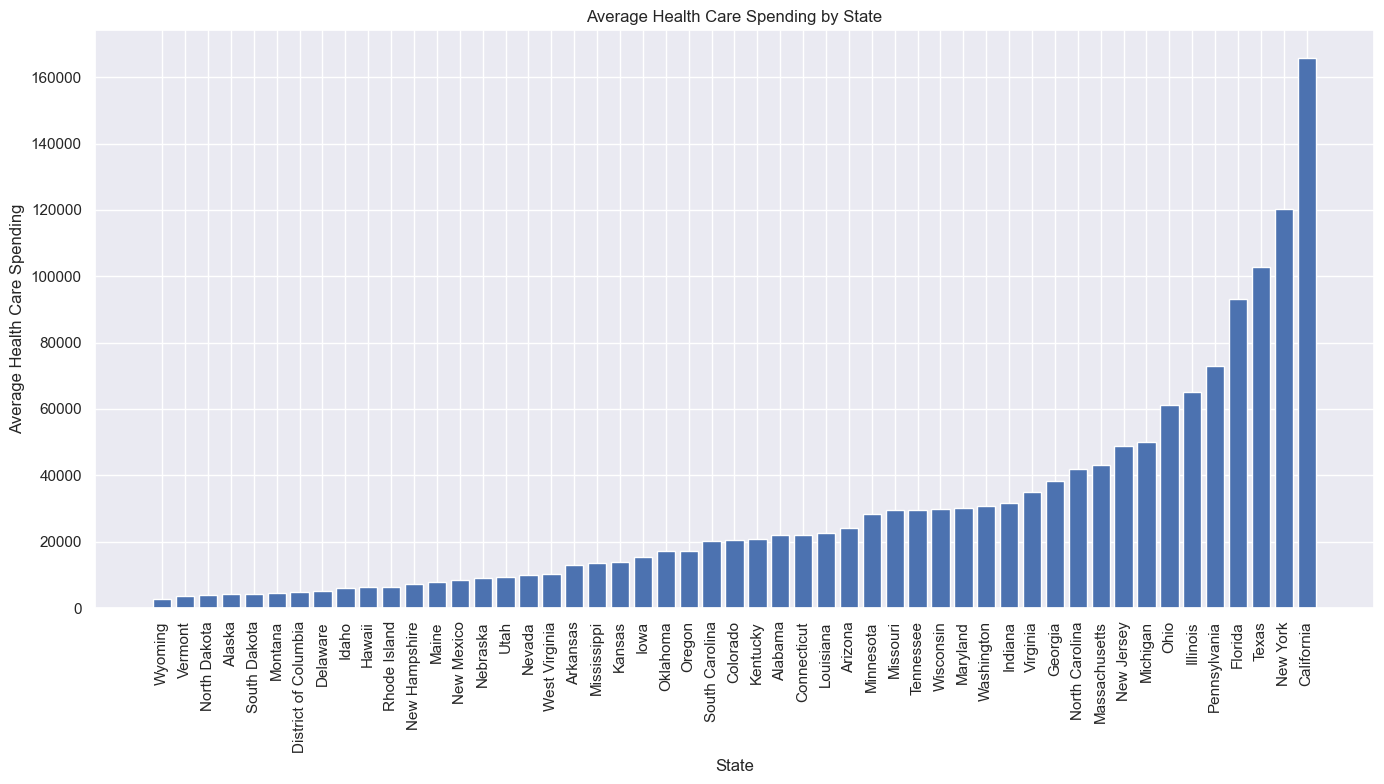

In [22]:
plt.figure(figsize=(14, 8))
plt.bar(healthcare_average_df.index, healthcare_average_df.values)
plt.xticks(rotation=90)
plt.xlabel('State')
plt.ylabel('Average Health Care Spending')
plt.title('Average Health Care Spending by State')

plt.tight_layout()
plt.show()